<h1 style="color:#56B4E9;">Week 6 — Day 4</h1>

<h2 style="color:#0072B2;">Building and Training a Neural Network in Keras</h2>

### ECG-Based Multi-Label Cardiac Diagnosis Using PTB-XL

During Day 3, the ECG data was prepared and three learning rates were compared. Adam with a learning rate of `0.001` produced the best validation loss.

Day 4 converts the previous training experiment into a complete Keras modeling workflow. A basic neural network will first be trained and diagnosed. Batch Normalization and Dropout will then be added, and the two models will be compared using the same data and training configuration.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Build a neural network using the Keras Sequential API.
- Explain the role of Input and Dense layers.
- Compile a multi-label model using Adam and Binary Cross-Entropy.
- Train the model using training and validation data.
- Read and diagnose the training history.
- Apply Batch Normalization and Dropout.
- Compare a basic network with a regularized network.
- Evaluate the selected model and compare it with the Day 1 baseline.

<h2 style="color:#0072B2;">1. From Training Theory to Keras</h2>

The previous days explained the internal training process:

$$
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Weight Update}
$$

TensorFlow performs the mathematical operations, gradient calculations, and parameter updates. Keras provides a high-level interface for describing and training the network.

The main Keras workflow is:

$$
\text{Build}
\rightarrow
\text{Compile}
\rightarrow
\text{Fit}
\rightarrow
\text{Evaluate}
$$

- `Build`: Define the layers and their order.
- `Compile`: Select the optimizer, loss function, and metrics.
- `Fit`: Train the network and record its history.
- `Evaluate`: Measure performance on data that was not used for training.

In [1]:
from pathlib import Path
import ast
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

I0000 00:00:1787757346.483598    3627 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787757346.487810    3627 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787757347.168445    3627 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787757352.851453    3627 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

DATA_DIR = Path("../../cardiac-patient-monitoring/data/raw/ptb-xl")
metadata_path = DATA_DIR / "ptbxl_database.csv"
statements_path = DATA_DIR / "scp_statements.csv"

print("TensorFlow version:", tf.__version__)
print("Metadata exists:", metadata_path.exists())
print("Statements exist:", statements_path.exists())
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
Metadata exists: True
Statements exist: True
GPU devices: []


E0000 00:00:1787757388.089722    3627 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
metadata = pd.read_csv(metadata_path, index_col="ecg_id")
scp_statements = pd.read_csv(statements_path, index_col=0)

metadata["scp_codes_dict"] = metadata["scp_codes"].apply(
    ast.literal_eval
)

print("Metadata shape:", metadata.shape)
print("SCP statements shape:", scp_statements.shape)

Metadata shape: (21799, 28)
SCP statements shape: (71, 12)


In [4]:
available_ids = []

for ecg_id, row in metadata.iterrows():
    record_path = DATA_DIR / row["filename_lr"]

    dat_exists = record_path.with_suffix(".dat").exists()
    hea_exists = record_path.with_suffix(".hea").exists()

    if dat_exists and hea_exists:
        available_ids.append(ecg_id)

available_metadata = metadata.loc[available_ids].copy()

print("Total ECGs in metadata:", len(metadata))
print("Complete ECG recordings:", len(available_metadata))

Total ECGs in metadata: 21799
Complete ECG recordings: 21799


In [5]:
def get_diagnostic_classes(code_dictionary):
    classes = []

    for code in code_dictionary:
        if code not in scp_statements.index:
            continue

        is_diagnostic = scp_statements.loc[code, "diagnostic"]
        diagnostic_class = scp_statements.loc[
            code, "diagnostic_class"
        ]

        if (
            is_diagnostic == 1
            and pd.notna(diagnostic_class)
            and diagnostic_class not in classes
        ):
            classes.append(diagnostic_class)

    return classes

In [6]:
available_metadata["diagnostic_classes"] = available_metadata[
    "scp_codes_dict"
].apply(get_diagnostic_classes)

selection_classes = ["NORM", "MI", "STTC", "CD", "HYP"]
target_classes = ["MI", "STTC", "CD", "HYP"]

for class_name in selection_classes:
    available_metadata[class_name] = available_metadata[
        "diagnostic_classes"
    ].apply(
        lambda classes: int(class_name in classes)
    )

model_data = available_metadata[
    available_metadata[selection_classes].sum(axis=1) > 0
].copy()

print("ECGs used for modeling:", len(model_data))
print("\nTarget classes:", target_classes)

ECGs used for modeling: 21388

Target classes: ['MI', 'STTC', 'CD', 'HYP']


<h2 style="color:#0072B2;">2. Preparing the Model Inputs</h2>

The neural network will not receive the raw ECG waveform directly. Each recording will be represented using six statistical features from every one of its 12 leads:

- Mean
- Standard deviation
- Minimum
- Maximum
- Range
- Root Mean Square

Therefore, the total number of input features is:

$$
12\ Leads \times 6\ Features = 72\ Features
$$

The same feature representation and the same official PTB-XL folds used during Day 3 will be retained. This ensures that differences between the upcoming experiments are caused by the model configuration rather than changes in the data.

In [7]:
feature_rows = []

for ecg_id, row in model_data.iterrows():
    signal, information = wfdb.rdsamp(
        str(DATA_DIR / row["filename_lr"])
    )

    features = {"ecg_id": ecg_id}

    for lead_index, lead_name in enumerate(information["sig_name"]):
        lead = signal[:, lead_index]

        features[f"{lead_name}_mean"] = np.mean(lead)
        features[f"{lead_name}_std"] = np.std(lead)
        features[f"{lead_name}_min"] = np.min(lead)
        features[f"{lead_name}_max"] = np.max(lead)
        features[f"{lead_name}_range"] = (
            np.max(lead) - np.min(lead)
        )
        features[f"{lead_name}_rms"] = np.sqrt(
            np.mean(lead ** 2)
        )

    feature_rows.append(features)

X = pd.DataFrame(feature_rows).set_index("ecg_id")

y = model_data.loc[
    X.index, target_classes
].astype("float32")

print("Feature table shape:", X.shape)
print("Target table shape:", y.shape)

Feature table shape: (21388, 72)
Target table shape: (21388, 4)


In [8]:
train_ids = model_data[
    model_data["strat_fold"].between(1, 8)
].index

validation_ids = model_data[
    model_data["strat_fold"] == 9
].index

test_ids = model_data[
    model_data["strat_fold"] == 10
].index

X_train = X.loc[X.index.intersection(train_ids)]
X_validation = X.loc[X.index.intersection(validation_ids)]
X_test = X.loc[X.index.intersection(test_ids)]

y_train = y.loc[X_train.index]
y_validation = y.loc[X_validation.index]
y_test = y.loc[X_test.index]

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
).astype("float32")

X_validation_scaled = scaler.transform(
    X_validation
).astype("float32")

X_test_scaled = scaler.transform(
    X_test
).astype("float32")

y_train_array = y_train.to_numpy(dtype="float32")
y_validation_array = y_validation.to_numpy(dtype="float32")
y_test_array = y_test.to_numpy(dtype="float32")

In [10]:
print(
    "Training:",
    X_train_scaled.shape,
    y_train_array.shape
)

print(
    "Validation:",
    X_validation_scaled.shape,
    y_validation_array.shape
)

print(
    "Test:",
    X_test_scaled.shape,
    y_test_array.shape
)

print("\nTraining label counts:")
print(y_train.sum().astype(int))

print(
    "\nTraining rows with four zero disease labels:",
    int((y_train.sum(axis=1) == 0).sum())
)

print(
    "Missing or infinite input values:",
    int(
        np.size(X_train_scaled)
        - np.isfinite(X_train_scaled).sum()
    )
)

Training: (17084, 72) (17084, 4)
Validation: (2146, 72) (2146, 4)
Test: (2158, 72) (2158, 4)

Training label counts:
MI      4379
STTC    4186
CD      3907
HYP     2119
dtype: int64

Training rows with four zero disease labels: 7243
Missing or infinite input values: 0


<h3 style="color:#009E73;">Prepared Data Results</h3>

All `21,799` PTB-XL recordings were available. After selecting recordings that belonged to at least one of the five diagnostic superclasses, `21,388` ECGs remained.

Each ECG was represented using 72 statistical features, while the target contained four independent disease labels.

The official PTB-XL folds produced:

- Training: `(17084, 72)`
- Validation: `(2146, 72)`
- Test: `(2158, 72)`

The 7,243 training rows containing four zero target labels were retained. These rows mainly represent normal ECGs and teach the network how the absence of all four target diseases appears.

StandardScaler was fitted using the training data only and was then applied to the validation and test sets. This prevents information from the validation or test data from influencing model preparation.

<h2 style="color:#0072B2;">3. Building the Basic Sequential Model</h2>

The Keras Sequential API places layers in a fixed order. The output of each layer becomes the input of the following layer.

The basic architecture is:

$$
72 \rightarrow 32 \rightarrow 16 \rightarrow 4
$$

- The input contains the 72 standardized ECG features.
- The first hidden layer contains 32 neurons.
- The second hidden layer contains 16 neurons.
- ReLU introduces non-linearity in both hidden layers.
- Four independent sigmoid neurons produce the probabilities of MI, STTC, CD, and HYP.

In [11]:
def build_basic_model():
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(72,)),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            16,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            4,
            activation="sigmoid"
        )
    ])

    return model

In [12]:
basic_model = build_basic_model()

basic_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy"
        )
    ]
)

basic_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,932 (11.45 KB)

 Trainable params: 2,932 (11.45 KB)

 Non-trainable params: 0 (0.00 B)

<h2 style="color:#0072B2;">4. Compiling and Training the Basic Model</h2>

Building the model defines its architecture, but it does not train the network.

The `compile()` step determines how the network will learn:

- Adam applies the parameter updates.
- The learning rate controls the update size.
- Binary Cross-Entropy measures the error across the four independent labels.
- Binary Accuracy records the fraction of individual label decisions predicted correctly.

The `fit()` step then performs the complete training loop repeatedly over the training data.

In [13]:
EPOCHS = 40
BATCH_SIZE = 32

basic_history = basic_model.fit(
    X_train_scaled,
    y_train_array,
    validation_data=(
        X_validation_scaled,
        y_validation_array
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.7879 - loss: 0.4656 - val_binary_accuracy: 0.8164 - val_loss: 0.4315
Epoch 2/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8212 - loss: 0.4107 - val_binary_accuracy: 0.8234 - val_loss: 0.4235
Epoch 3/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8268 - loss: 0.4005 - val_binary_accuracy: 0.8242 - val_loss: 0.4177
Epoch 4/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8302 - loss: 0.3942 - val_binary_accuracy: 0.8250 - val_loss: 0.4138
Epoch 5/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8323 - loss: 0.3886 - val_binary_accuracy: 0.8248 - val_loss: 0.4091
Epoch 6/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8343 - loss: 0.3843 - val_binary_accuracy: 0.8260 - val_loss: 0.4071
Epoch 7/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8352 - loss: 0.3810 - val_binary_accuracy: 0.8284 - val_loss: 0.4018
Epoch 

In [14]:
print("History keys:")
print(basic_history.history.keys())

print(
    "\nInitial training loss:",
    round(basic_history.history["loss"][0], 4)
)

print(
    "Final training loss:",
    round(basic_history.history["loss"][-1], 4)
)

print(
    "Initial validation loss:",
    round(basic_history.history["val_loss"][0], 4)
)

print(
    "Final validation loss:",
    round(basic_history.history["val_loss"][-1], 4)
)

History keys:
dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

Initial training loss: 0.4656
Final training loss: 0.3539
Initial validation loss: 0.4315
Final validation loss: 0.4021


In [15]:
basic_best_epoch = (
    np.argmin(basic_history.history["val_loss"]) + 1
)

basic_best_validation_loss = np.min(
    basic_history.history["val_loss"]
)

basic_final_validation_loss = basic_history.history[
    "val_loss"
][-1]

print("Best validation epoch:", basic_best_epoch)

print(
    "Best validation loss:",
    round(basic_best_validation_loss, 4)
)

print(
    "Final validation loss:",
    round(basic_final_validation_loss, 4)
)

Best validation epoch: 29
Best validation loss: 0.3946
Final validation loss: 0.4021


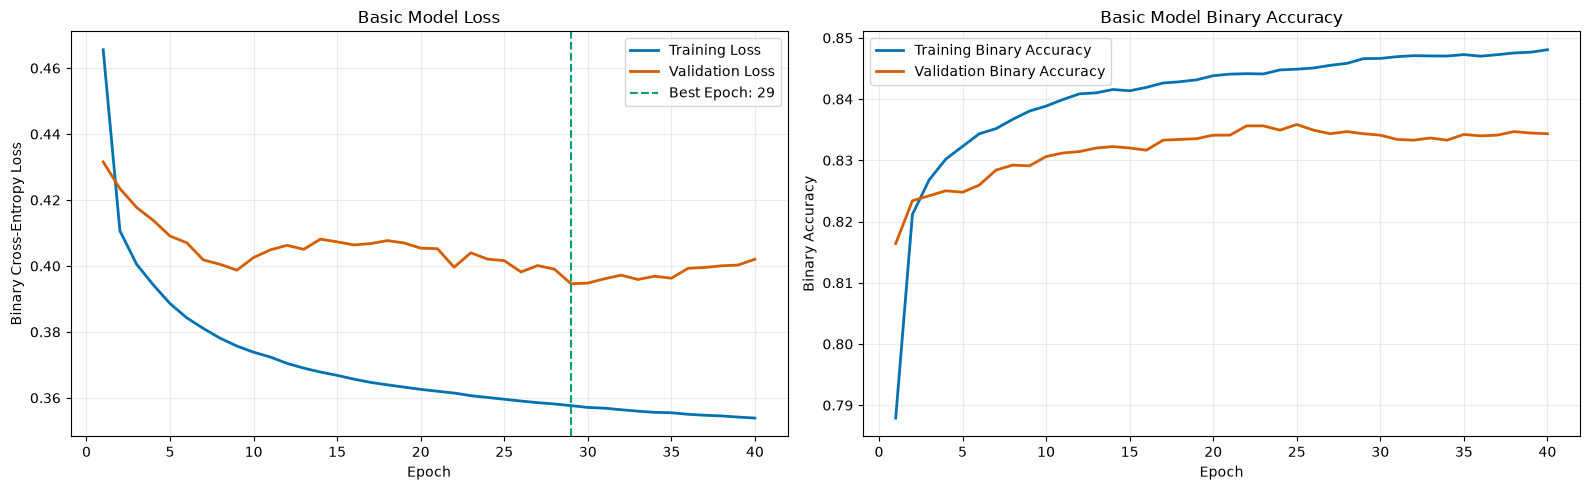

In [16]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

axes[0].plot(
    epochs_range,
    basic_history.history["loss"],
    label="Training Loss",
    color="#0072B2",
    linewidth=2
)

axes[0].plot(
    epochs_range,
    basic_history.history["val_loss"],
    label="Validation Loss",
    color="#D55E00",
    linewidth=2
)

axes[0].axvline(
    basic_best_epoch,
    color="#009E73",
    linestyle="--",
    label=f"Best Epoch: {basic_best_epoch}"
)

axes[0].set_title("Basic Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    epochs_range,
    basic_history.history["binary_accuracy"],
    label="Training Binary Accuracy",
    color="#0072B2",
    linewidth=2
)

axes[1].plot(
    epochs_range,
    basic_history.history["val_binary_accuracy"],
    label="Validation Binary Accuracy",
    color="#D55E00",
    linewidth=2
)

axes[1].set_title("Basic Model Binary Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [17]:
basic_validation_probabilities = basic_model.predict(
    X_validation_scaled,
    verbose=0
)

THRESHOLD = 0.5

basic_validation_predictions = (
    basic_validation_probabilities >= THRESHOLD
).astype(int)

print("Probability shape:", basic_validation_probabilities.shape)
print("Prediction shape:", basic_validation_predictions.shape)

print("\nFirst five probability rows:")
print(
    np.round(
        basic_validation_probabilities[:5],
        3
    )
)

print("\nFirst five binary predictions:")
print(basic_validation_predictions[:5])

Probability shape: (2146, 4)
Prediction shape: (2146, 4)

First five probability rows:
[[0.236 0.114 0.383 0.007]
 [0.01  0.03  0.02  0.001]
 [0.107 0.028 0.089 0.004]
 [0.216 0.32  0.106 0.041]
 [0.13  0.127 0.13  0.148]]

First five binary predictions:
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


In [18]:
print(
    classification_report(
        y_validation_array,
        basic_validation_predictions,
        target_names=target_classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          MI       0.68      0.38      0.49       540
        STTC       0.61      0.30      0.41       528
          CD       0.78      0.52      0.63       495
         HYP       0.68      0.37      0.48       268

   micro avg       0.70      0.40      0.50      1831
   macro avg       0.69      0.39      0.50      1831
weighted avg       0.69      0.40      0.50      1831
 samples avg       0.24      0.21      0.21      1831



<h3 style="color:#D55E00;">Basic Model Diagnosis</h3>

The basic model learned successfully. Training loss decreased from `0.4656` to `0.3539`, while validation loss reached its minimum value of `0.3946` at epoch 29.

After epoch 29, training loss continued decreasing while validation loss gradually increased to `0.4021`. This represents mild overfitting: the model continued improving on the training data without producing an equivalent improvement on unseen validation data.

At a threshold of `0.5`, the model produced:

- Macro Precision: `0.69`
- Macro Recall: `0.39`
- Macro F1-score: `0.50`

Binary Accuracy reached approximately `0.83` on the validation set, but this value was influenced by the large number of negative labels. The much lower Macro Recall shows that the model missed many true disease cases.

The next experiment will add Batch Normalization and Dropout to stabilize training and reduce overfitting while keeping the remaining training configuration unchanged.

<h2 style="color:#0072B2;">5. Batch Normalization and Dropout</h2>

Batch Normalization stabilizes the values passed between layers. For each training batch, it normalizes the layer values and then applies two learned parameters:

$$
\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\epsilon}}
$$

$$
y=\gamma\hat{x}+\beta
$$

The parameters $\gamma$ and $\beta$ allow the network to learn the most useful scale and shift instead of forcing every normalized value to remain fixed.

Dropout randomly disables a fraction of layer outputs during training. With a dropout rate of `0.3`, approximately 30% of the outputs are temporarily disabled during each training step.

The disabled neurons change from one batch to another. This prevents the network from depending too strongly on specific neurons and can reduce overfitting.

Dropout is active only during training. During validation, evaluation, and prediction, all neurons are used.

In [19]:
def build_regularized_model():
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(72,)),

        tf.keras.layers.Dense(
            32,
            use_bias=False
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(
            16,
            use_bias=False
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(
            4,
            activation="sigmoid"
        )
    ])

    return model

In [20]:
regularized_model = build_regularized_model()

regularized_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy"
        )
    ]
)

regularized_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,076 (12.02 KB)

 Trainable params: 2,980 (11.64 KB)

 Non-trainable params: 96 (384.00 B)

In [21]:
regularized_history = regularized_model.fit(
    X_train_scaled,
    y_train_array,
    validation_data=(
        X_validation_scaled,
        y_validation_array
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.7582 - loss: 0.5122 - val_binary_accuracy: 0.8056 - val_loss: 0.4363
Epoch 2/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.7977 - loss: 0.4526 - val_binary_accuracy: 0.8073 - val_loss: 0.4233
Epoch 3/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8006 - loss: 0.4438 - val_binary_accuracy: 0.8092 - val_loss: 0.4196
Epoch 4/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8037 - loss: 0.4395 - val_binary_accuracy: 0.8094 - val_loss: 0.4172
Epoch 5/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.8058 - loss: 0.4349 - val_binary_accuracy: 0.8112 - val_loss: 0.4148
Epoch 6/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8084 - loss: 0.4319 - val_binary_accuracy: 0.8120 - val_loss: 0.4119
Epoch 7/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8090 - loss: 0.4296 - val_binary_accuracy: 0.8120 - val_loss: 0.4093
Epoch 

In [22]:
regularized_best_epoch = (
    np.argmin(
        regularized_history.history["val_loss"]
    ) + 1
)

regularized_best_validation_loss = np.min(
    regularized_history.history["val_loss"]
)

regularized_final_validation_loss = (
    regularized_history.history["val_loss"][-1]
)

print(
    "Initial training loss:",
    round(
        regularized_history.history["loss"][0],
        4
    )
)

print(
    "Final training loss:",
    round(
        regularized_history.history["loss"][-1],
        4
    )
)

print(
    "Best validation epoch:",
    regularized_best_epoch
)

print(
    "Best validation loss:",
    round(
        regularized_best_validation_loss,
        4
    )
)

print(
    "Final validation loss:",
    round(
        regularized_final_validation_loss,
        4
    )
)

Initial training loss: 0.5122
Final training loss: 0.411
Best validation epoch: 39
Best validation loss: 0.3947
Final validation loss: 0.3954


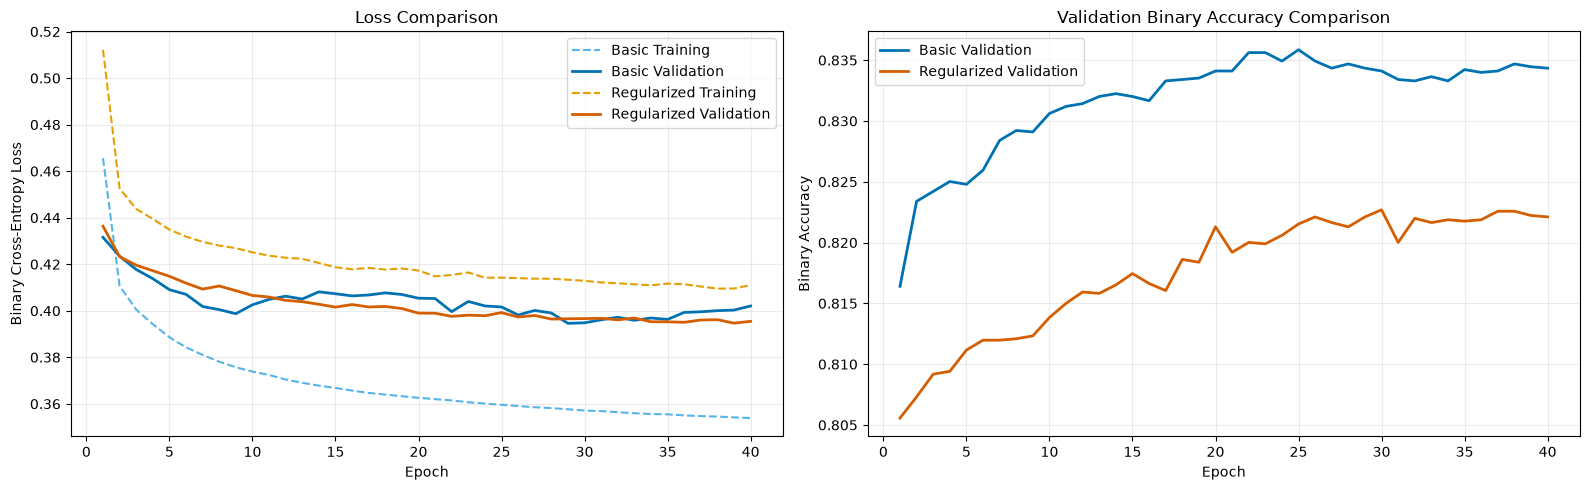

In [23]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

axes[0].plot(
    epochs_range,
    basic_history.history["loss"],
    label="Basic Training",
    color="#56B4E9",
    linestyle="--"
)

axes[0].plot(
    epochs_range,
    basic_history.history["val_loss"],
    label="Basic Validation",
    color="#0072B2",
    linewidth=2
)

axes[0].plot(
    epochs_range,
    regularized_history.history["loss"],
    label="Regularized Training",
    color="#E69F00",
    linestyle="--"
)

axes[0].plot(
    epochs_range,
    regularized_history.history["val_loss"],
    label="Regularized Validation",
    color="#D55E00",
    linewidth=2
)

axes[0].set_title("Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    epochs_range,
    basic_history.history["val_binary_accuracy"],
    label="Basic Validation",
    color="#0072B2",
    linewidth=2
)

axes[1].plot(
    epochs_range,
    regularized_history.history["val_binary_accuracy"],
    label="Regularized Validation",
    color="#D55E00",
    linewidth=2
)

axes[1].set_title("Validation Binary Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [24]:
regularized_validation_probabilities = (
    regularized_model.predict(
        X_validation_scaled,
        verbose=0
    )
)

regularized_validation_predictions = (
    regularized_validation_probabilities >= THRESHOLD
).astype(int)

print(
    classification_report(
        y_validation_array,
        regularized_validation_predictions,
        target_names=target_classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          MI       0.72      0.19      0.29       540
        STTC       0.65      0.11      0.18       528
          CD       0.81      0.45      0.58       495
         HYP       0.79      0.22      0.34       268

   micro avg       0.76      0.24      0.37      1831
   macro avg       0.74      0.24      0.35      1831
weighted avg       0.74      0.24      0.35      1831
 samples avg       0.16      0.13      0.13      1831



<h2 style="color:#0072B2;">6. Comparing the Two Networks</h2>

Batch Normalization and Dropout changed the behavior of the network substantially.

The regularized model maintained a smaller gap between training and validation loss. Its final training loss was `0.4110`, while its final validation loss was `0.3954`. This indicates that Dropout successfully prevented the network from fitting the training data too closely.

Its best validation loss was `0.3947`, which was almost identical to the basic model's best value of `0.3946`.

However, the disease-specific metrics revealed an important disadvantage. Macro Recall decreased from `0.39` to `0.24`, and Macro F1-score decreased from `0.50` to `0.35`.

The regularized model produced higher precision but missed substantially more true disease cases. The 30% Dropout applied after both hidden layers was therefore too restrictive for this small network.

Regularization successfully reduced overfitting, but reducing overfitting did not automatically produce better diagnostic performance. Because disease detection is the priority, the basic model is selected for final evaluation at the current threshold.

In [25]:
from sklearn.metrics import (
    precision_recall_fscore_support
)

def calculate_macro_metrics(
    y_true,
    y_prediction
):
    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_prediction,
            average="macro",
            zero_division=0
        )
    )

    return precision, recall, f1


basic_precision, basic_recall, basic_f1 = (
    calculate_macro_metrics(
        y_validation_array,
        basic_validation_predictions
    )
)

regularized_precision, regularized_recall, regularized_f1 = (
    calculate_macro_metrics(
        y_validation_array,
        regularized_validation_predictions
    )
)

validation_comparison = pd.DataFrame({
    "Model": [
        "Basic",
        "BatchNorm + Dropout"
    ],
    "Best Validation Loss": [
        basic_best_validation_loss,
        regularized_best_validation_loss
    ],
    "Best Epoch": [
        basic_best_epoch,
        regularized_best_epoch
    ],
    "Final Validation Loss": [
        basic_final_validation_loss,
        regularized_final_validation_loss
    ],
    "Macro Precision": [
        basic_precision,
        regularized_precision
    ],
    "Macro Recall": [
        basic_recall,
        regularized_recall
    ],
    "Macro F1": [
        basic_f1,
        regularized_f1
    ]
})

display(
    validation_comparison.round(4)
)

,Model,Best Validation Loss,Best Epoch,Final Validation Loss,Macro Precision,Macro Recall,Macro F1
0,Basic,0.3946,29,0.4021,0.6905,0.3947,0.5009
1,BatchNorm + Dropout,0.3947,39,0.3954,0.7437,0.2415,0.3511


<h2 style="color:#0072B2;">7. Final Test Evaluation</h2>

The model was selected using validation results only. The test set was not used to choose between the basic and regularized networks.

The basic model is now evaluated once on the official PTB-XL test fold. This provides a less biased estimate of its performance on unseen ECG recordings.

The threshold remains fixed at `0.5` so that the test set does not influence model or threshold selection.

In [26]:
basic_test_loss, basic_test_binary_accuracy = (
    basic_model.evaluate(
        X_test_scaled,
        y_test_array,
        verbose=0
    )
)

basic_test_probabilities = basic_model.predict(
    X_test_scaled,
    verbose=0
)

basic_test_predictions = (
    basic_test_probabilities >= THRESHOLD
).astype(int)

print(
    "Basic model test loss:",
    round(basic_test_loss, 4)
)

print(
    "Basic model test binary accuracy:",
    round(basic_test_binary_accuracy, 4)
)

Basic model test loss: 0.403
Basic model test binary accuracy: 0.8289


In [27]:
print(
    classification_report(
        y_test_array,
        basic_test_predictions,
        target_names=target_classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          MI       0.67      0.35      0.46       550
        STTC       0.57      0.29      0.38       521
          CD       0.75      0.49      0.59       496
         HYP       0.70      0.37      0.49       262

   micro avg       0.67      0.37      0.48      1829
   macro avg       0.67      0.38      0.48      1829
weighted avg       0.67      0.37      0.48      1829
 samples avg       0.22      0.20      0.20      1829



<h2 style="color:#0072B2;">8. Fair Comparison with the Day 1 Baseline</h2>

The provisional Day 1 baseline was trained before the complete PTB-XL download was available. It used 1,990 ECG recordings and predicted five labels, including NORM.

The current neural network uses 21,388 recordings and predicts four disease labels. Directly comparing these results would therefore be invalid.

To preserve the Day 1 baseline method while making the comparison fair, the same One-vs-Rest Logistic Regression model will be retrained using:

- The complete dataset.
- The same 72 features.
- The same four disease targets.
- The same official training and test folds.
- The same standardized input values.

Only results produced under these shared conditions will be compared.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

baseline_model = OneVsRestClassifier(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=SEED
    )
)

baseline_model.fit(
    X_train_scaled,
    y_train_array
)

baseline_test_predictions = baseline_model.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test_array,
        baseline_test_predictions,
        target_names=target_classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          MI       0.44      0.69      0.54       550
        STTC       0.38      0.58      0.46       521
          CD       0.48      0.70      0.57       496
         HYP       0.33      0.69      0.45       262

   micro avg       0.41      0.66      0.51      1829
   macro avg       0.41      0.66      0.50      1829
weighted avg       0.42      0.66      0.51      1829
 samples avg       0.28      0.37      0.30      1829



In [29]:
baseline_test_precision, baseline_test_recall, baseline_test_f1 = (
    calculate_macro_metrics(
        y_test_array,
        baseline_test_predictions
    )
)

neural_test_precision, neural_test_recall, neural_test_f1 = (
    calculate_macro_metrics(
        y_test_array,
        basic_test_predictions
    )
)

test_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression Baseline",
        "Basic Neural Network"
    ],
    "Macro Precision": [
        baseline_test_precision,
        neural_test_precision
    ],
    "Macro Recall": [
        baseline_test_recall,
        neural_test_recall
    ],
    "Macro F1": [
        baseline_test_f1,
        neural_test_f1
    ]
})

display(
    test_comparison.round(4)
)

,Model,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression Baseline,0.4086,0.6642,0.5037
1,Basic Neural Network,0.6717,0.3751,0.4803


<h2 style="color:#0072B2;">9. Test Results and Baseline Comparison</h2>

The selected basic neural network achieved the following test results:

- Test Binary Cross-Entropy Loss: `0.4030`
- Test Binary Accuracy: `0.8289`
- Macro Precision: `0.6717`
- Macro Recall: `0.3751`
- Macro F1-score: `0.4803`

The close validation and test results indicate that the model's behavior generalized consistently to the official test fold. However, the disease-specific report showed that the current threshold produced insufficient recall.

The fairly retrained Logistic Regression baseline achieved:

- Macro Precision: `0.4086`
- Macro Recall: `0.6642`
- Macro F1-score: `0.5037`

The neural network produced substantially higher precision, meaning that its positive predictions were more reliable. However, Logistic Regression detected a much larger proportion of the true disease cases and also achieved a slightly higher Macro F1-score.

Therefore, the current neural network has not yet beaten the baseline according to the project's recall priority or Macro F1-score. Its main limitation is not failure to learn, but overly conservative positive predictions at the fixed threshold of `0.5`.

<h2 style="color:#0072B2;">10. Day 4 Conclusion</h2>

Day 4 implemented the complete Keras modeling workflow for multi-label ECG diagnosis.

A basic Sequential neural network was built with 72 inputs, two ReLU hidden layers containing 32 and 16 neurons, and four independent sigmoid outputs. The network was compiled using Adam with a learning rate of `0.001`, Binary Cross-Entropy, and Binary Accuracy, then trained for 40 epochs.

The training history revealed mild overfitting. Training loss continued decreasing, while validation loss reached its best value of `0.3946` at epoch 29 and then increased slightly.

A second network added Batch Normalization and 30% Dropout after both hidden layers. This configuration reduced the gap between training and validation loss, demonstrating more stable generalization. However, it also reduced model capacity too strongly. Macro Recall decreased from `0.3947` to `0.2415`, and Macro F1-score decreased from `0.5009` to `0.3511` on the validation set.

The basic model was therefore selected and evaluated on the official test fold. It achieved Macro Precision of `0.6717`, Macro Recall of `0.3751`, and Macro F1-score of `0.4803`.

For a fair comparison, the Day 1 Logistic Regression method was retrained using the complete dataset, the same four targets, and the same official folds. It achieved Macro Recall of `0.6642` and Macro F1-score of `0.5037`, outperforming the current neural network on the project's most important metrics.

### Final Findings

- Keras successfully automated forward propagation, Backpropagation, and Adam updates.
- The basic network learned useful patterns but showed mild overfitting.
- Batch Normalization and Dropout improved loss stability.
- Applying 30% Dropout after both hidden layers over-regularized the small network.
- Binary Accuracy was misleading because negative labels were more frequent.
- Disease-specific Precision, Recall, and F1-score were necessary for proper evaluation.
- The neural network was more precise but substantially less sensitive than the baseline.
- The current neural network did not yet beat the Logistic Regression baseline.

### Next Step

Day 5 will improve the neural network systematically using validation data. The work will include EarlyStopping, saving the best weights, controlled hyperparameter experiments, and methods for improving disease recall before producing the final Sprint 1 comparison.